# __Demo 01 - Proximity analysis__
### Basic usage example of processing and representing __Proximity__ data.

#### __What is a proximity analysis?__
A proximity analysis measures how close or accessible certain locations are to others within a defined area.
In an urban context, it often uses street networks (such as those from OpenStreetMap) to calculate distances or travel times between points of interest (POIs) — for example, how long it takes to walk from a residential block to a park, a school, or a public transport stop.

#### __How can a proximity analysis be used?__
Proximity analysis is a key tool in urban planning, transportation, and equity studies. It helps researchers and decision-makers to:
* Evaluate accessibility to essential services such as education, healthcare, or green areas.
* Identify spatial inequalities and underserved neighborhoods.
* Support urban design decisions based on walkability and connectivity.
* Model travel behavior and potential catchment areas for public facilities.
* Integrate accessibility data into urban indicators or planning dashboards.

#### __About this notebook__
This notebook displays a __demo process to be used be used to calculate proximity__ to a given points of interest within a given area of interest, __and then represent the data__ using Observatory's design style.

The notebook consists of the following steps:
* __Import libraries__
* __Analysis configuration__
* __Prepare the area of interest and the points of interest__
* __Download OSM roads and intersections__
* __Calculate proximity from each node to the points of interest__
* __Proximity analysis to hexgrid__
* __Proximity visualization__

## __Import libraries__

In order to use the functions required to process and represent data, we've developed a code library called `odc`, which stores functions that use other python libraries for the analysis and representation of data.

In [1]:
import pandas as pd
import geopandas as gpd
import odc
import matplotlib.pyplot as plt
from shapely.geometry import Polygon

## __Analysis configuration__

This cell specifies the location of input data and other parameters used within the proximity analysis.

In [2]:
# --------------- Location of input data
# Area of interest - Directory with location of input layer containing a polygon geometry that defines the area of interest were the analysis is to be performed.
aoi_dir = "../data/demo_files/aoibuffer_saltillo_32614.gpkg"
# Points of interest - Directory with location of input layer containing several points to which proximity is to be measured.
pois_dir = "../data/demo_files/pois_saltillo_32614.gpkg"

# --------------- Analysis parameters
# Projection CRS (str) - CRS used when projecting features to perform geoprocessing (e.g. "6372" could be used anywere in Mexico)
# [Optional, function calculate_time_to_pois() defaults to "EPSG:6372"]
projection_crs = 'EPSG:32614'
# Walking speed (float) - Speed of travel in km/hr for the proximity calculation. (e.g. a pedestrian speed could be set at around 4km/hr)
walking_speed = 4
# Points of interest name (str) - Name to be used within the analysis and returned in the output. (e.g. pois_dir containing schools)
pois_name = 'schools'
# Count amount of pois at a cetain distance (tupple) - Tupple which, if first value is True, uses the second value to count the number of pois within a certain walking time from each node. (e.g. count the number of schools at a 10 minute walk)
count_pois = (True,15)
# Output hexgrid resolution (int between 8 and 11) - Specifies resolution of H3 hexagonal cells. For more information consult resolutions in https://h3geo.org/
hex_res = 9

# --------------- Output saving
# Output directory for nodes and hexagons (str) - Directory with the location where the output nodes and hexs with proximity analysis will be saved
output_dir = "../data/demo_files/outputs_proximity/"

## __Prepare the area of interest and the points of interest__

Both the area of interest and the points of interest are __set to EPSG:4326.__

<Axes: >

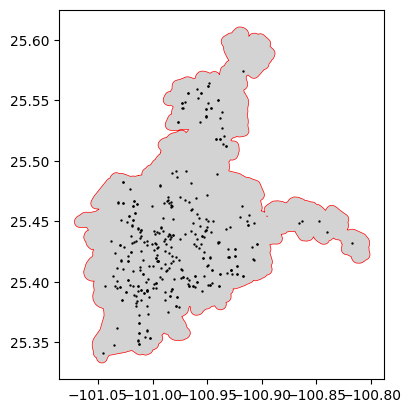

In [3]:
# --------------- Prepare the area of interest CRS
aoi_gdf = gpd.read_file(aoi_dir)
if aoi_gdf.crs is None:
    aoi_gdf = aoi_gdf.set_crs('EPSG:4326')
elif aoi_gdf.crs != 'EPSG:4326':
    aoi_gdf = aoi_gdf.to_crs('EPSG:4326')

# --------------- Prepare the points of interest CRS
pois_gdf = gpd.read_file(pois_dir)
if pois_gdf.crs is None:
    pois_gdf = pois_gdf.set_crs('EPSG:4326')
elif pois_gdf.crs != 'EPSG:4326':
    pois_gdf = pois_gdf.to_crs('EPSG:4326')

# Show input data (This part creates the following map for visualization purposes)
fig,ax = plt.subplots()
pois_gdf.plot(ax=ax,zorder=2,markersize=.5,color='black')
aoi_gdf.plot(ax=ax,zorder=1, facecolor='lightgray',edgecolor='red',lw=.5)

## __Download OSM roads and intersections__

The function __odc.download_osm_network()__ is used to __download from Open Street Map the navigable network G formed by nodes (intersections) and edges (streets)__ within the provided area of interest.

In [4]:
G, nodes_gdf, edges_gdf = odc.download_osm_network(area_of_interest = aoi_gdf, # Area of interest 
                                           method='from_bbox', # 'from_polygon' crops the network to the available network, 'from_bbox' crops the network to a bounding box around the aoi
                                           network_type='all'
                                          )

print(f"Downloaded {len(nodes_gdf)} nodes and {len(edges_gdf)} edges.")

Downloaded 46137 nodes and 120702 edges.


In [5]:
# Save the edges localy (Used on demos 2 and 3 visualizations)
edges_gdf.to_file(f"../data/demo_files/edges_gdf.gpkg", driver="GPKG")

<Axes: >

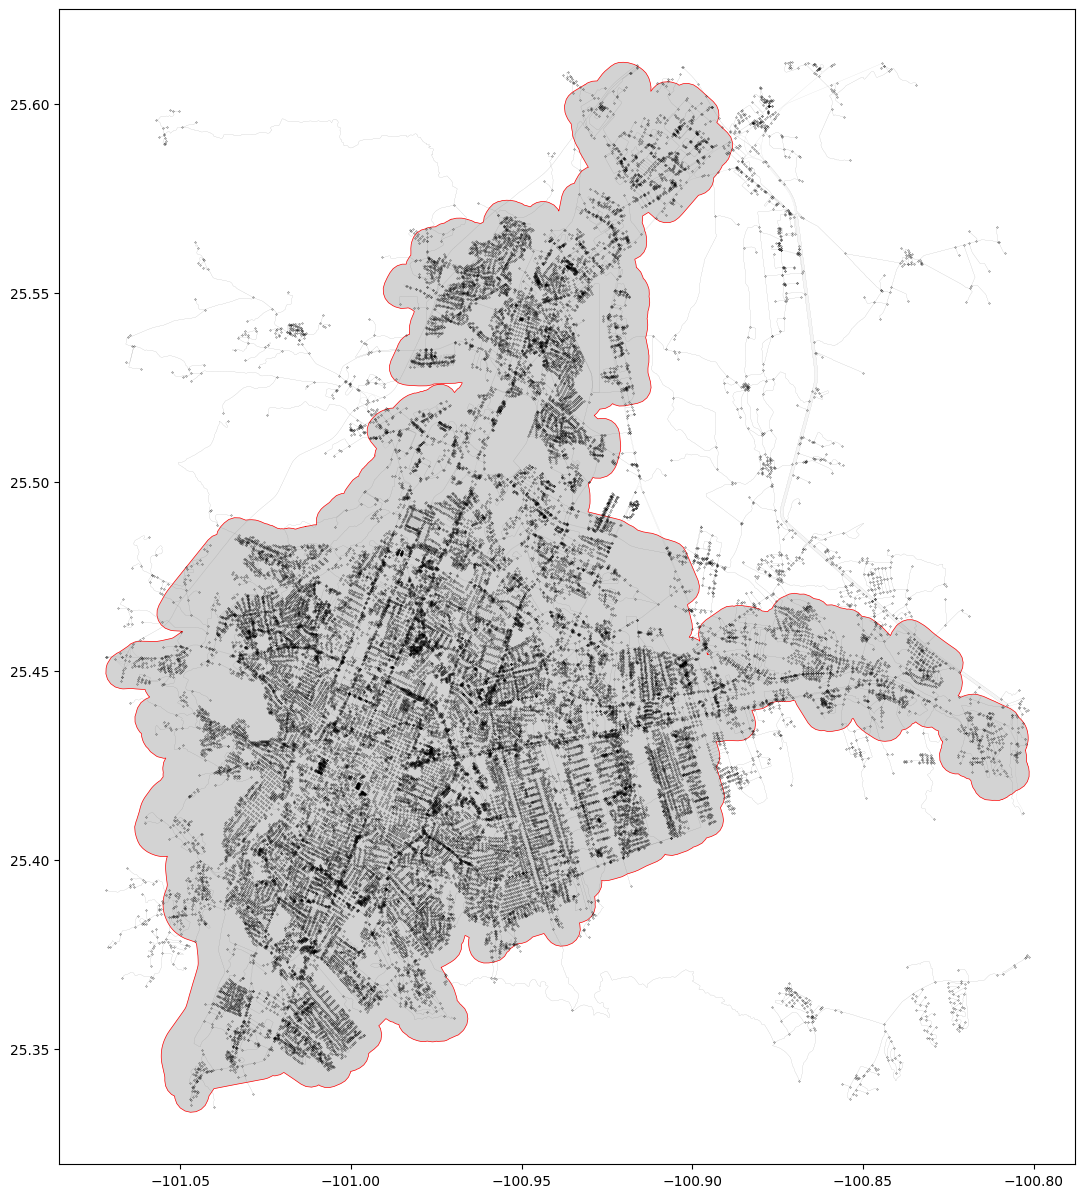

In [6]:
# Show network data (This part creates the following map for visualization purposes)
fig,ax = plt.subplots(figsize=(45,15))
nodes_gdf.plot(ax=ax,zorder=3, facecolor='black',markersize=.05)
edges_gdf.plot(ax=ax,zorder=2, color='gray',lw=.05)
aoi_gdf.plot(ax=ax,zorder=1, facecolor='lightgray',edgecolor='red',lw=.5)

## __Calculate proximity from each node to the points of interest__

The function __odc.calculate_time_to_pois()__ recieves as input the downloaded area of interest network, the points of interest and the analysis configuration previously set, and __returns all nodes (intersections) with the specified proximity data.__

In [7]:
nodes_with_time = odc.calculate_time_to_pois(G = G,
                                             nodes = nodes_gdf,
                                             edges = edges_gdf,
                                             pois = pois_gdf,
                                             poi_name = pois_name,
                                             walking_speed = walking_speed,
                                             count_pois = count_pois,
                                             projected_crs = projection_crs
                                            )
# Show
print(nodes_with_time.crs)
print(nodes_with_time.shape)
nodes_with_time.head(2)

EPSG:4326
(46137, 6)


,osmid,time_schools,schools_15min,x,y,geometry
0,291729314,30.102733,0,-100.806483,25.438236,POINT (-100.80648 25.43824)
1,291729528,33.585864,0,-100.805196,25.430500,POINT (-100.8052 25.4305)


#### __Save the nodes proximity analysis to output directory__

In [8]:
nodes_with_time.to_file(output_dir+f'nodes_with_{pois_name}_time.gpkg', driver="GPKG")
print(f"Results saved to {output_dir}")

Results saved to ../data/demo_files/outputs_proximity/


## __Proximity analysis to hexgrid__

#### __Create hexgrid in area of analysis__

In order to visualize a territorial analysis of proximity, the proximity analysis can be integrated into hexagons. Function __odc.create_hexagonal_grid()__ can be used to create the hexgrid.

In [9]:
hex_gdf = odc.create_hexagonal_grid(aoi_gdf, resolution=hex_res)

# Show
print(hex_gdf.crs)
print(hex_gdf.shape)
hex_gdf.head(2)

EPSG:4326
(2698, 2)


,hex_id_9,geometry
0,8948a04cbafffff,"POLYGON ((-100.94044 25.43311, -100.93915 25.4..."
1,8948a2b6b4fffff,"POLYGON ((-100.93014 25.54393, -100.92886 25.5..."


#### __Integrate proximity analysis into hexgrid__

Function __odc.group_points_by_bins()__ can be used to summarize point data to polygons specifying aggregation functions.

In [10]:
if count_pois[0]:
    aggregation_func={f'time_{pois_name}':'mean',
                      f'{pois_name}_{count_pois[1]}min':'mean'}
else:
    aggregation_func={f'time_{pois_name}':'mean'}    

hex_proximity = odc.group_points_by_bins(points=nodes_with_time,
                                         bins=hex_gdf,
                                         bin_id_column=f'hex_id_{hex_res}',
                                         aggregate_columns=list(aggregation_func.keys()),
                                         aggregation_func=aggregation_func
                                        )

# Show
print(hex_proximity.crs)
print(hex_proximity.shape)
hex_proximity.head(2)

EPSG:4326
(2698, 4)


,hex_id_9,geometry,time_schools,schools_15min
0,8948a04cbafffff,"POLYGON ((-100.94044 25.43311, -100.93915 25.4...",14.990942,1.357143
1,8948a2b6b4fffff,"POLYGON ((-100.93014 25.54393, -100.92886 25.5...",0.000000,0.000000


#### __Save the hexgrid proximity analysis to output directory__

In [11]:
hex_proximity.to_file(output_dir+f'hexs_with_{pois_name}_time.gpkg', driver="GPKG")
print(f"Results saved to {output_dir}")

Results saved to ../data/demo_files/outputs_proximity/


## __Proximity visualization__

#### __Visualization__ - odc.plot_proximity() just specifying column 

Function __odc.plot_proximity()__ was designed to recieve proximity data and identify the data to be plotted according to the column name.
* Passing columns with 'time' or 'max' assumes data is minutes (time) and plots divided data in 15 minutes bins.
* Passing columns with 'min' assumes data is amenity count and plots a color palette for the amount of amenities.

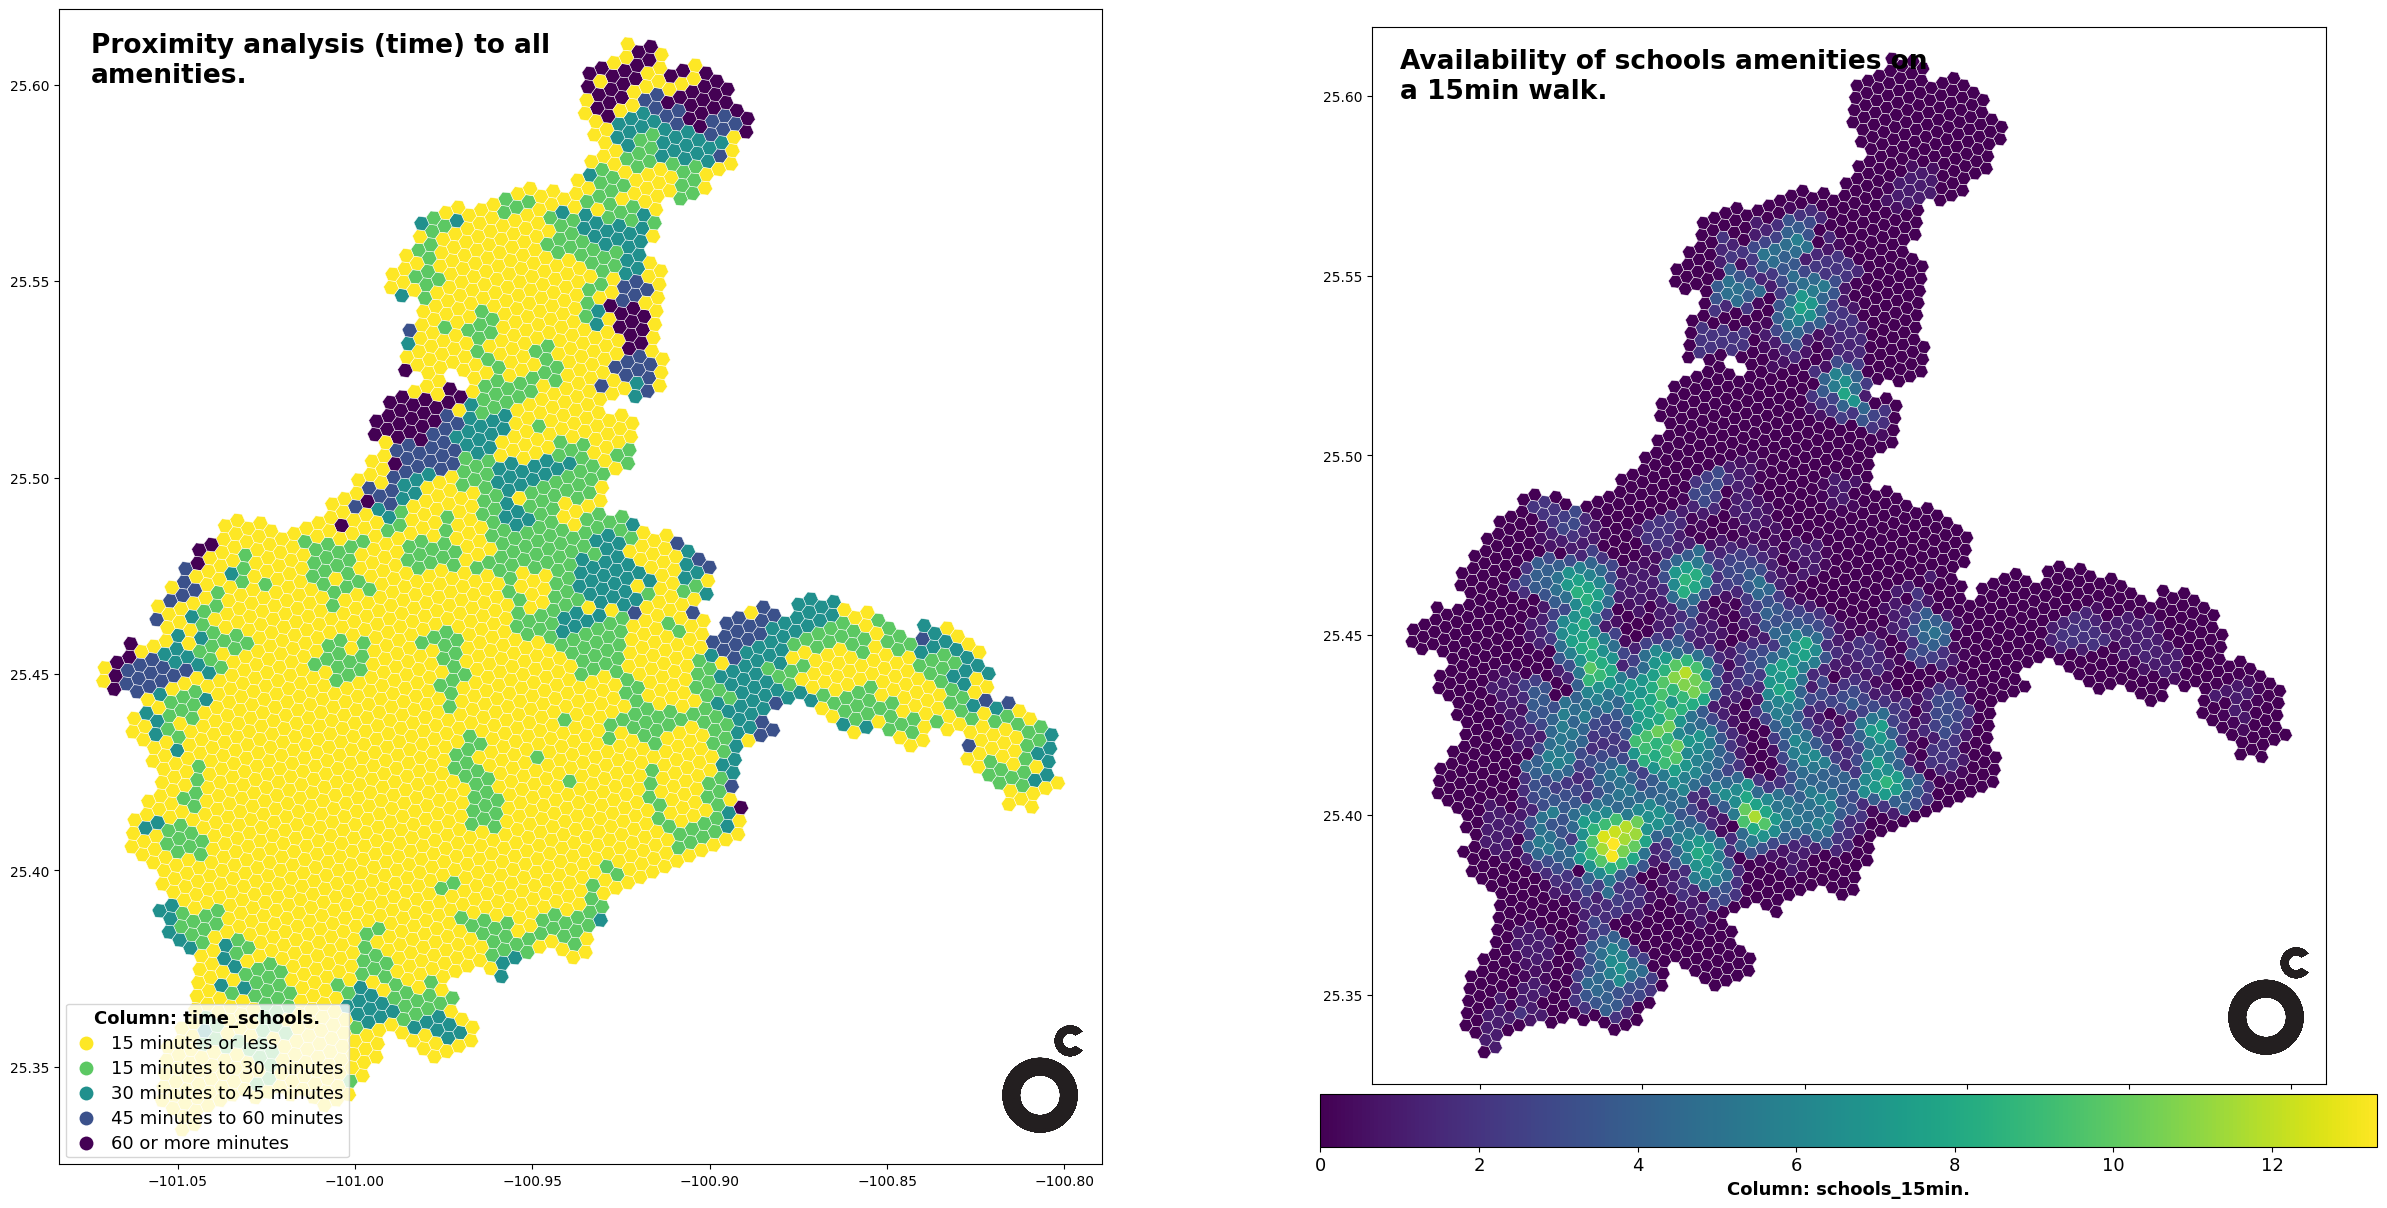

In [12]:
fig,axs = plt.subplots(1,2,figsize=(30,15))

odc.plot_proximity(data_gdf = hex_proximity,
                   column = f'time_{pois_name}',
                   ax=axs[0]
                  )

odc.plot_proximity(data_gdf = hex_proximity,
                   column = f'{pois_name}_{count_pois[1]}min',
                   ax=axs[1]
                  )

#### __Visualization__ - odc.plot_proximity() adding additional data

Keyword arguments can be added to function __odc.plot_proximity()__ to add additional data to the plot, like the __area of interest's name, and main streets__. Also, the maps __can be saved by to pdf or png__ by using the saving arguments.

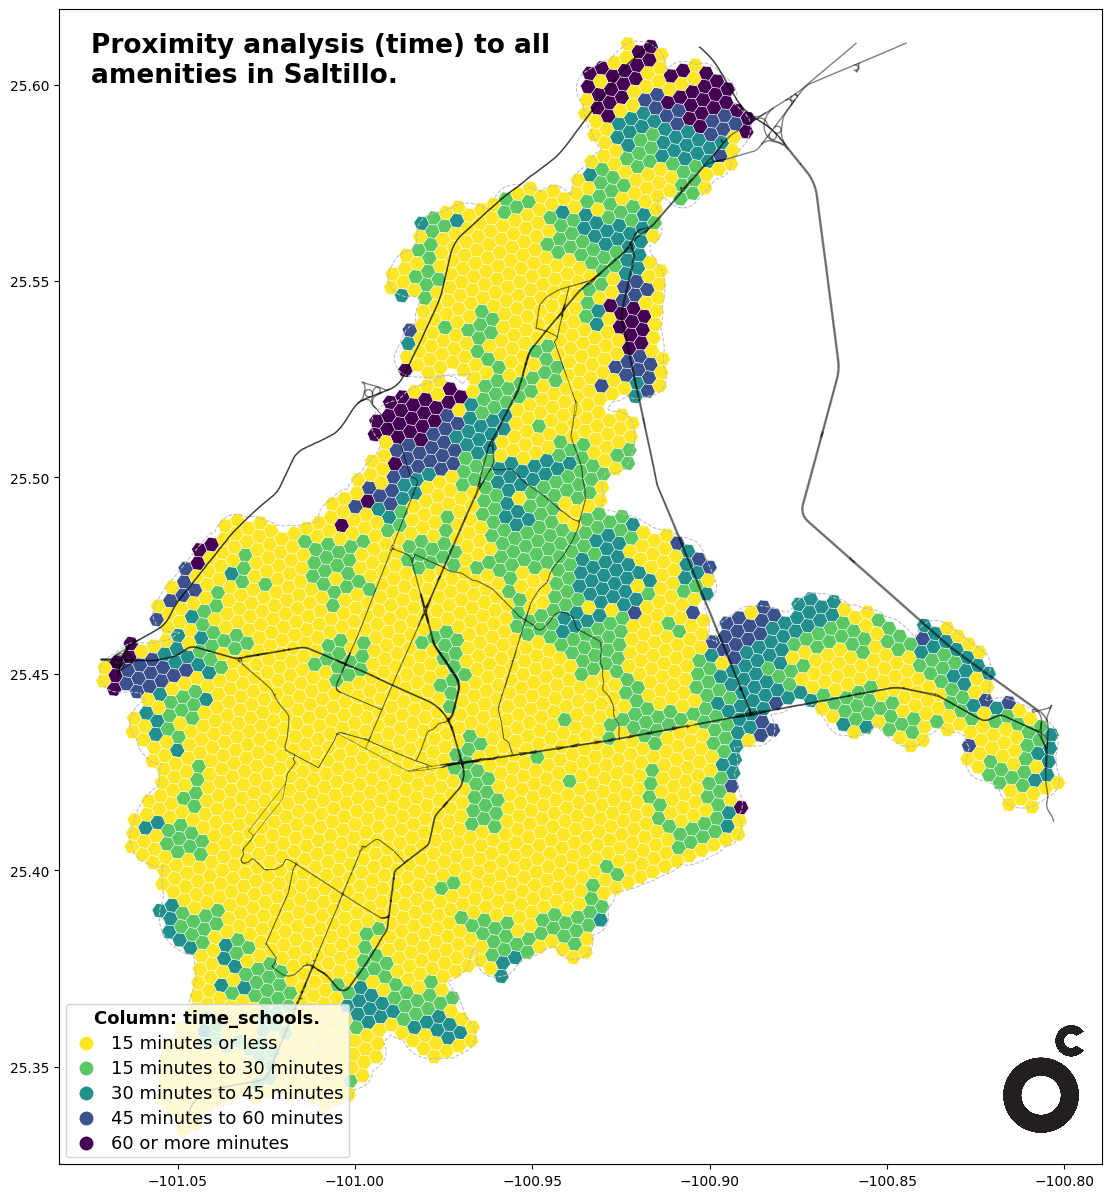

In [13]:
kwargs_dict = {"location_name":'Saltillo',
               "plot_osmnx_edges": (True, edges_gdf),
               "plot_boundary": (True, aoi_gdf),
               "save_png":(True,output_dir+f'{pois_name}_proximity_time'),
               "output_transparency":True,
               "output_dpi":150
              }

fig,ax = plt.subplots(figsize=(15,15))

odc.plot_proximity(data_gdf = hex_proximity,
                   column = f'time_{pois_name}',
                   ax=ax,
                   **kwargs_dict
                  )

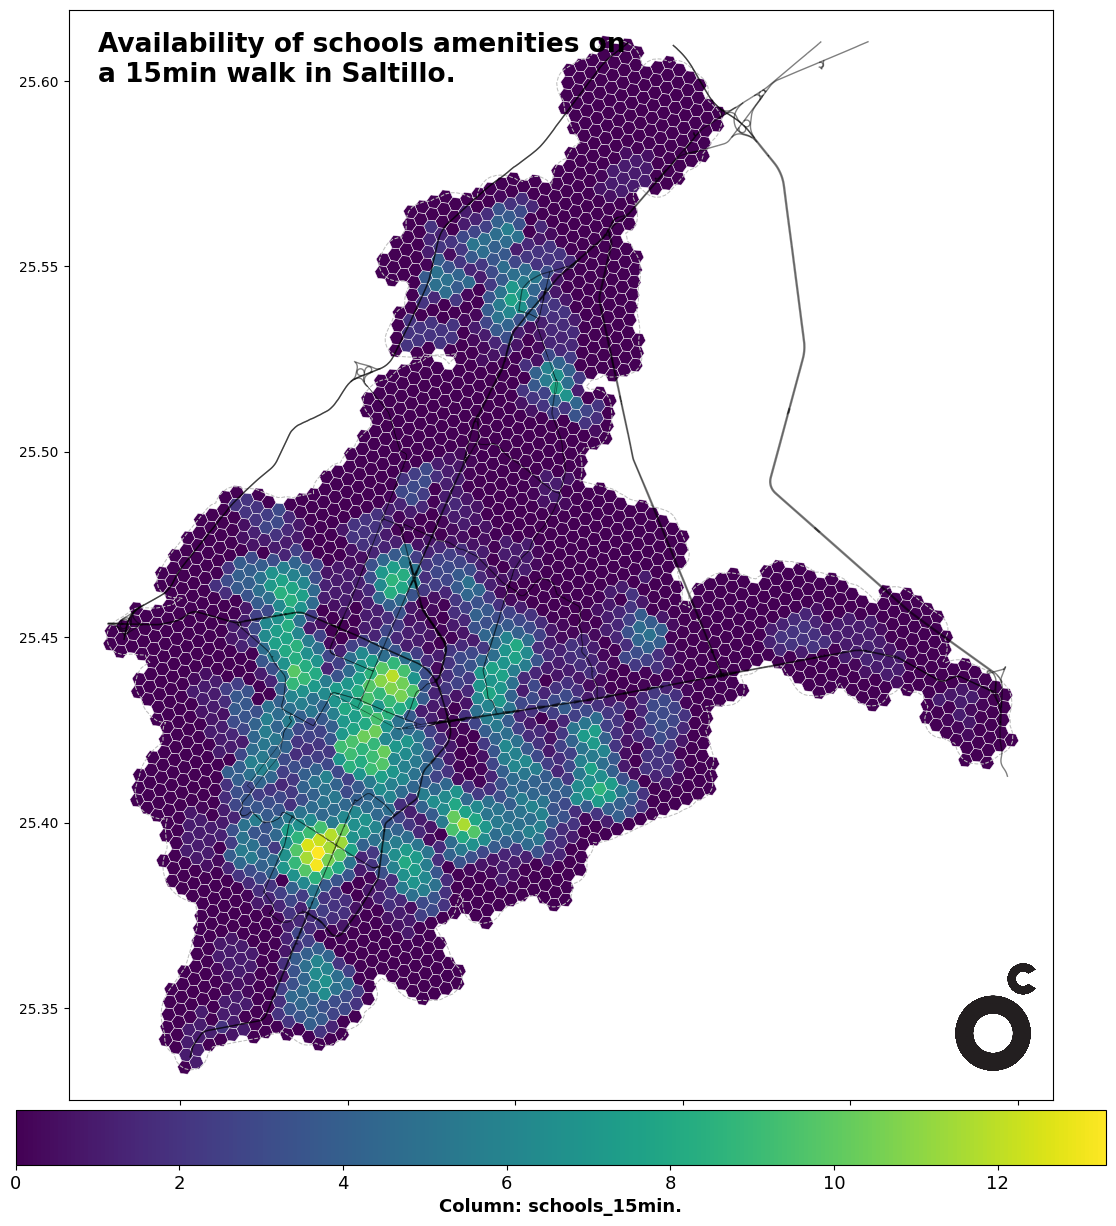

In [14]:
kwargs_dict = {"location_name":'Saltillo',
               "plot_osmnx_edges": (True, edges_gdf),
               "plot_boundary": (True, aoi_gdf),
               "save_pdf":(True,output_dir+f'{pois_name}_proximity_count'),
               "output_transparency":True,
               "output_dpi":150
              }
fig,ax = plt.subplots(figsize=(15,15))

odc.plot_proximity(data_gdf = hex_proximity,
                   column = f'{pois_name}_{count_pois[1]}min',
                   ax=ax,
                   **kwargs_dict
                  )